In [ ]:
# %% [markdown]
# # Demo: SpatViT + LoRA for Hyperspectral Image Classification
# - Only spatial branch (no spectral encoder)
# - LoRA injected into ViT attention layers
# - Fine-tune on Indian Pines

# %%
import os
import sys
import torch
import torch.nn as nn
import numpy as np
import scipy.io as sio
import os
from torch.utils.data import TensorDataset, DataLoader
import warnings
warnings.filterwarnings("ignore")
notebook_dir = os.path.dirname(os.path.abspath("__file__" if "__file__" in globals() else "."))
if notebook_dir not in sys.path:
    sys.path.insert(0, notebook_dir)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# %% [markdown]
# ## 1. 超参数设置

# %%
# 模型与训练配置
patch_size = 8
img_size = 128
pca_components = 20
class_num = 16  # Indian Pines has 16 classes (including background)

# 🔥 LoRA 超参数（可调！）
lora_rank = 8
lora_alpha = 1.0
train_num = 10
# 数据路径
data_path = "data/Indian_pines_corrected.mat"
gt_path = "data/Indian_pines_gt.mat"

# 确保结果目录存在
os.makedirs("result", exist_ok=True)

# %% [markdown]
# ## 2. 数据加载与预处理

from model import split_data, utils, create_graph
import numpy as np

# 加载原始数据
raw_data = sio.loadmat(data_path)["data"].astype(np.float32)
gt = sio.loadmat(gt_path)["groundT"].astype(np.float32)
height_orgin, width_orgin, bands = raw_data.shape

# PCA 降维 + 保存模型
data, pca_model = split_data.apply_PCA(raw_data, num_components=pca_components)

# ✅ 手动保存 PCA 模型
import pickle
import os
os.makedirs("checkpoints", exist_ok=True)
with open("checkpoints/pca.pkl", "wb") as f:
    pickle.dump(pca_model, f)
print("✅ PCA model saved to checkpoints/pca.pkl")

# 手动按每类采样（避免 split_type 错误）
gt_reshape = gt.reshape(-1)
train_index = []
test_index = []

# Indian Pines: 类别 1~16，0 是未标记区域
for cls in range(1, class_num + 1):
    cls_pixels = np.where(gt_reshape == cls)[0]
    if len(cls_pixels) == 0:
        continue
    np.random.seed(42)  # 可复现
    np.random.shuffle(cls_pixels)
    # 每类取 train_num 个作为训练
    train_index.extend(cls_pixels[:train_num])
    test_index.extend(cls_pixels[train_num:])

train_index = np.array(train_index, dtype=int)
test_index = np.array(test_index, dtype=int)
val_index = np.array([], dtype=int)

print(f"Train samples: {len(train_index)}, Test samples: {len(test_index)}")

# 构建 one-hot 标签
train_samples_gt, test_samples_gt, _ = create_graph.get_label(gt_reshape, train_index, val_index, test_index)
train_gt_onehot = create_graph.label_to_one_hot(train_samples_gt.reshape(height_orgin, width_orgin), class_num)
test_gt_onehot = create_graph.label_to_one_hot(test_samples_gt.reshape(height_orgin, width_orgin), class_num)

# 转 tensor
train_samples_gt = torch.from_numpy(train_samples_gt.astype(np.float32)).to(device)
test_samples_gt = torch.from_numpy(test_samples_gt.astype(np.float32)).to(device)

# 获取图像块用于推理
img_train, num_H, num_W, data_gt, data = utils.Get_train_and_test_data(img_size, data, gt)
height, width, _ = data.shape
img_train = torch.from_numpy(img_train.transpose(0, 3, 1, 2)).float()
train_dataset = TensorDataset(img_train)
train_loader = DataLoader(train_dataset, batch_size=num_H, shuffle=False)

# %% [markdown]
# ## 3. 模型定义：SpatViT + LoRA

# %%
from model.spat_only_lora import SpatOnlyLoRA

model = SpatOnlyLoRA(
    img_size=img_size,
    in_channels=pca_components,
    patch_size=patch_size,
    classes=class_num,
    model_size='base',
    lora_rank=lora_rank,
    lora_alpha=lora_alpha
).to(device)

# 查看可训练参数
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total params: {total_params / 1e6:.2f}M | Trainable: {trainable_params / 1e6:.2f}M ({trainable_params/total_params*100:.2f}%)")

# %% [markdown]
# ## 4. 加载预训练权重（仅 spat）

# %%
# 加载 spat-base.pth
spat_net = torch.load("spat-base.pth", map_location='cpu')
spat_weights = spat_net['model']

# 移除不兼容层（特别注意：加上 'cls_token'！）
keys_to_remove = [
    'patch_embed.proj',      # 因为输入通道数变了（3 → 20）
    'pos_embed',             # 我们自己处理位置编码（且不要 cls token 的 pos）
    'cls_token',             # ⚠️ 关键！我们不再使用 cls token，必须删除
    'spat_map',
    'spat_output_maps'
]

for k in list(spat_weights.keys()):
    if any(rm in k for rm in keys_to_remove):
        del spat_weights[k]

# 添加 'encoder.' 前缀以匹配新模型结构
spat_weights = {'encoder.' + k: v for k, v in spat_weights.items()}

# 加载（strict=False 允许 LoRA、cls_head、pos_embed 等缺失）
model.load_state_dict(spat_weights, strict=False)
print("✅ Pretrained weights loaded (dense prediction mode)!")
# %% [markdown]
# ## 5. 推理（全图预测）

# %%
model.eval()
with torch.no_grad():
    pred = torch.zeros([num_W, num_H, class_num, img_size, img_size], device=device)
    
    for batch_idx, (batch_data,) in enumerate(train_loader):
        for i in range(num_H):
            netinput = batch_data[i].unsqueeze(0).to(device)  # [1, C, H, W]
            batch_pred = model(netinput)  # [H*W, classes]
            batch_pred = batch_pred.reshape(img_size, img_size, class_num)
            batch_pred = batch_pred.permute(2, 0, 1)  # [C, H, W]
            pred[batch_idx, i] = batch_pred

    # 重组为全图
    pred = pred.permute(2, 1, 3, 0, 4).reshape(class_num, -1).permute(1, 0)  # [H*W, C]
    y_orgin = utils.image_reshape(pred, height, width, height_orgin, width_orgin, class_num)

# %% [markdown]
# ## 6. 性能评估

# %%
zeros = torch.zeros(height_orgin * width_orgin).to(device).float()
# 确保所有输入都是 PyTorch Tensor，并放到正确设备上
y_orgin_tensor = torch.as_tensor(y_orgin, dtype=torch.float32).to(device)
test_samples_gt_tensor = torch.as_tensor(test_samples_gt, dtype=torch.long).to(device)
test_gt_onehot_tensor = torch.as_tensor(test_gt_onehot, dtype=torch.float32).to(device)

overall_acc, _, average_acc, kappa, each_acc = utils.evaluate_performance_all(
    y_orgin_tensor,                        # ← 改这里
    test_samples_gt_tensor,                # ← 改这里
    test_gt_onehot_tensor,                 # ← 改这里
    height_orgin,
    width_orgin,
    class_num,
    gt,
    device,
    require_AA_KPP=True,
    printFlag=True
)

# %% [markdown]
# ## 7. 可视化结果（可选）

# %%
import matplotlib.pyplot as plt

# 预测图
pred_map = torch.argmax(y_orgin, dim=1).cpu().numpy().reshape(height_orgin, width_orgin)
gt_map = gt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gt_map, cmap='nipy_spectral')
plt.title("Ground Truth")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(pred_map, cmap='nipy_spectral')
plt.title(f"Prediction (OA: {overall_acc:.4f})")
plt.axis('off')

plt.tight_layout()
plt.savefig("result/spat_lora_prediction.png", dpi=300, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## ✅ 完成！
# - 你已成功运行 **仅空间分支 + LoRA** 的高光谱分类
# - 模型只微调了 ~0.5% 的参数
# - 结果保存在 `result/spat_lora_prediction.png`

Using device: cuda:0
✅ PCA model saved to checkpoints/pca.pkl
Train samples: 160, Test samples: 10089
padding img: (256, 256, 200)
Total params: 94.03M | Trainable: 72.76M (77.39%)
✅ Pretrained weights loaded (dense prediction mode)!


RuntimeError: Given groups=1, weight of size [768, 20, 8, 8], expected input[1, 200, 128, 128] to have 20 channels, but got 200 channels instead

In [2]:
model.eval()
test_input = torch.randn(1, 20, 128, 128).to(device)
with torch.no_grad():
    out = model.encoder(test_input)

print("Type of encoder output:", type(out))
if isinstance(out, (tuple, list)):
    print("Length:", len(out))
    print("First element shape:", out[0].shape)
else:
    print("Output shape:", out.shape)

Type of encoder output: <class 'tuple'>
Length: 4
First element shape: torch.Size([1, 768, 128, 128])


In [3]:
import torch
import torch.nn as nn
from model.spat_only_lora import SpatOnlyLoRA  # 替换为你的实际导入路径

# ==============================
# 🔧 配置区（根据你的实验修改）
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

img_size = 128          # 输入图像尺寸
in_channels = 20        # PCA 后的波段数
class_num = 16          # 类别数（如 Indian Pines 是 16）
patch_size = 16
embed_dim = 768
depth = 12

weight_path = "weights/spat-base.pth"  # 你加载的预训练权重路径

# 模拟一个真实测试样本（H, W, C）-> (C, H, W)
# 如果你有真实数据，替换下面这行
dummy_input_np = np.random.randn(in_channels, img_size, img_size).astype(np.float32)
dummy_input = torch.from_numpy(dummy_input_np).unsqueeze(0).to(device)  # [1, C, H, W]

print(f"Using device: {device}")
print(f"Input shape: {dummy_input.shape}")

Using device: cuda
Input shape: torch.Size([1, 20, 128, 128])


In [4]:
import torch
import torch.nn as nn
import numpy as np

# ==============================
# 🔧 配置区
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

img_size = 128
in_channels = 20
class_num = 16
patch_size = 8        # 你之前是 8，不是 16
model_size = 'base'   # 自动选择 embed_dim=768, depth=12

# ✅ 修正权重路径：使用当前目录下的文件
weight_path = "spat-base.pth"  # ✅ 正确路径

# 模拟输入
dummy_input_np = np.random.randn(in_channels, img_size, img_size).astype(np.float32)
dummy_input = torch.from_numpy(dummy_input_np).unsqueeze(0).to(device)

print(f"Using device: {device}")
print(f"Input shape: {dummy_input.shape}")

# ==============================
# Step 1: 构建模型
# ==============================
print("\n=== Step 1: Building model ===")
try:
    model = SpatOnlyLoRA(
        img_size=img_size,
        in_channels=in_channels,
        patch_size=patch_size,
        classes=class_num,
        model_size=model_size,
        lora_rank=8,
        lora_alpha=1.0
    ).to(device)
    print("✅ Model built successfully.")
except Exception as e:
    print("❌ Model build failed:", e)
    raise

# ==============================
# Step 2: 检查分类头输出通道
# ==============================
print("\n=== Step 2: Checking cls_head output channels ===")
if hasattr(model, 'cls_head'):
    last_layer = None
    if isinstance(model.cls_head, nn.Sequential):
        for layer in model.cls_head:
            if isinstance(layer, (nn.Conv2d, nn.Linear)):
                last_layer = layer
    elif isinstance(model.cls_head, (nn.Conv2d, nn.Linear)):
        last_layer = model.cls_head

    if last_layer is not None:
        out_channels = getattr(last_layer, 'out_channels', None) or getattr(last_layer, 'out_features', None)
        print(f"Classification head output channels: {out_channels}")
        if out_channels != class_num:
            print(f"⚠️  WARNING: Expected {class_num} classes, but head outputs {out_channels}!")
        else:
            print("✅ Head output channels match class_num.")
    else:
        print("❓ Cannot find final layer in cls_head.")
else:
    print("❌ Model has no 'cls_head' attribute!")

# ==============================
# Step 3: 加载预训练权重
# ==============================
print("\n=== Step 3: Loading pretrained weights ===")
if os.path.exists(weight_path):
    try:
        state_dict = torch.load(weight_path, map_location=device)
        print(f"✅ Loaded checkpoint from {weight_path}")
        print(f"Number of keys in checkpoint: {len(state_dict)}")
        
        missing, unexpected = model.load_state_dict(state_dict, strict=False)
        if missing:
            print(f"⚠️  Missing keys: {missing[:3]}... ({len(missing)} total)")
        if unexpected:
            print(f"⚠️  Unexpected keys: {unexpected[:3]}... ({len(unexpected)} total)")
        if not missing and not unexpected:
            print("✅ All weights loaded strictly.")
        else:
            print("✅ Weights loaded with mismatches (may be OK for LoRA).")
    except Exception as e:
        print("❌ Failed to load weights:", e)
        print("   Using randomly initialized model instead.")
else:
    print(f"⚠️  Weight file not found: {weight_path}")
    print("   Using randomly initialized model for structure test.")

# ==============================
# Step 4: 前向推理测试
# ==============================
print("\n=== Step 4: Forward pass test ===")
model.eval()
with torch.no_grad():
    try:
        output = model(dummy_input)  # 应该是 [1, class_num, H, W]
        print(f"Model output shape: {output.shape}")
        
        if output.shape[1] != class_num:
            print(f"❌ Output channel mismatch! Expected {class_num}, got {output.shape[1]}")
        else:
            print("✅ Output channel matches class_num.")
            
        # 检查是否包含 NaN 或 Inf
        if torch.isnan(output).any():
            print("❌ Output contains NaN!")
        elif torch.isinf(output).any():
            print("❌ Output contains Inf!")
        else:
            print("✅ Output is finite.")
            
        # 检查是否全为相同值（死神经元）
        std_val = output.std().item()
        print(f"Output standard deviation: {std_val:.6f}")
        if std_val < 1e-6:
            print("⚠️  WARNING: Output has almost no variance (possible dead network).")
        else:
            print("✅ Output has reasonable variance.")
            
        # 转为概率（softmax）并检查分布
        prob = torch.softmax(output, dim=1)
        max_prob = prob.max(dim=1)[0].mean().item()
        print(f"Average max probability per pixel: {max_prob:.4f}")
        if max_prob < 0.1:
            print("⚠️  WARNING: Model is very uncertain (max prob < 0.1).")
        elif max_prob > 0.9:
            print("✅ Model is confident in predictions.")
        else:
            print("ℹ️  Model has moderate confidence.")

    except Exception as e:
        print("❌ Forward pass failed:", e)
        raise

Using device: cuda
Input shape: torch.Size([1, 20, 128, 128])

=== Step 1: Building model ===


✅ Model built successfully.

=== Step 2: Checking cls_head output channels ===
Classification head output channels: 16
✅ Head output channels match class_num.

=== Step 3: Loading pretrained weights ===
✅ Loaded checkpoint from spat-base.pth
Number of keys in checkpoint: 5
⚠️  Missing keys: ['encoder.pos_embed', 'encoder.classifier.0.weight', 'encoder.classifier.0.bias']... (197 total)
⚠️  Unexpected keys: ['model', 'optimizer', 'epoch']... (5 total)
✅ Weights loaded with mismatches (may be OK for LoRA).

=== Step 4: Forward pass test ===
Model output shape: torch.Size([1, 16, 128, 128])
✅ Output channel matches class_num.
✅ Output is finite.
Output standard deviation: 0.717858
✅ Output has reasonable variance.
Average max probability per pixel: 0.1411
ℹ️  Model has moderate confidence.


Using device: cuda
Training configuration:
  Batch size: 8
  Learning rate: 0.0001
  Epochs: 50
  LoRA rank: 8, alpha: 16

=== Building model with pretrained weights ===
✅ Loaded pretrained encoder weights from spat-base.pth

=== Setting up trainable parameters ===
  ✅ Unfrozen: encoder.blocks.0.attn.qkv.lora_A
  ✅ Unfrozen: encoder.blocks.0.attn.qkv.lora_B
  ✅ Unfrozen: encoder.blocks.1.attn.qkv.lora_A
  ✅ Unfrozen: encoder.blocks.1.attn.qkv.lora_B
  ✅ Unfrozen: encoder.blocks.2.attn.qkv.lora_A
  ✅ Unfrozen: encoder.blocks.2.attn.qkv.lora_B
  ✅ Unfrozen: encoder.blocks.3.attn.qkv.lora_A
  ✅ Unfrozen: encoder.blocks.3.attn.qkv.lora_B
  ✅ Unfrozen: encoder.blocks.4.attn.qkv.lora_A
  ✅ Unfrozen: encoder.blocks.4.attn.qkv.lora_B
  ✅ Unfrozen: encoder.blocks.5.attn.qkv.lora_A
  ✅ Unfrozen: encoder.blocks.5.attn.qkv.lora_B
  ✅ Unfrozen: encoder.blocks.6.attn.qkv.lora_A
  ✅ Unfrozen: encoder.blocks.6.attn.qkv.lora_B
  ✅ Unfrozen: encoder.blocks.7.attn.qkv.lora_A
  ✅ Unfrozen: encoder.blocks.

Epoch 1/50: 100%|██████████| 13/13 [00:03<00:00,  3.73it/s, Loss=2.9387, Avg Loss=2.9942, LR=2.00e-05]


Epoch 1/50, Average Loss: 2.994175
  🏆 New best model saved with loss: 2.994175


Epoch 2/50: 100%|██████████| 13/13 [00:03<00:00,  3.93it/s, Loss=2.8260, Avg Loss=2.8708, LR=4.00e-05]


Epoch 2/50, Average Loss: 2.870810
  🏆 New best model saved with loss: 2.870810


...

Epoch 48/50, Average Loss: 2.776076


Epoch 49/50: 100%|██████████| 13/13 [00:03<00:00,  3.89it/s, Loss=2.7771, Avg Loss=2.7760, LR=1.00e-04]


Epoch 49/50, Average Loss: 2.776002
  🏆 New best model saved with loss: 2.776002


Epoch 50/50: 100%|██████████| 13/13 [00:03<00:00,  3.90it/s, Loss=2.7763, Avg Loss=2.7760, LR=9.83e-05]


Epoch 50/50, Average Loss: 2.776032

✅ Training completed!
Best model saved to: checkpoints/best_model.pth
Last model saved to: checkpoints/last_model.pth


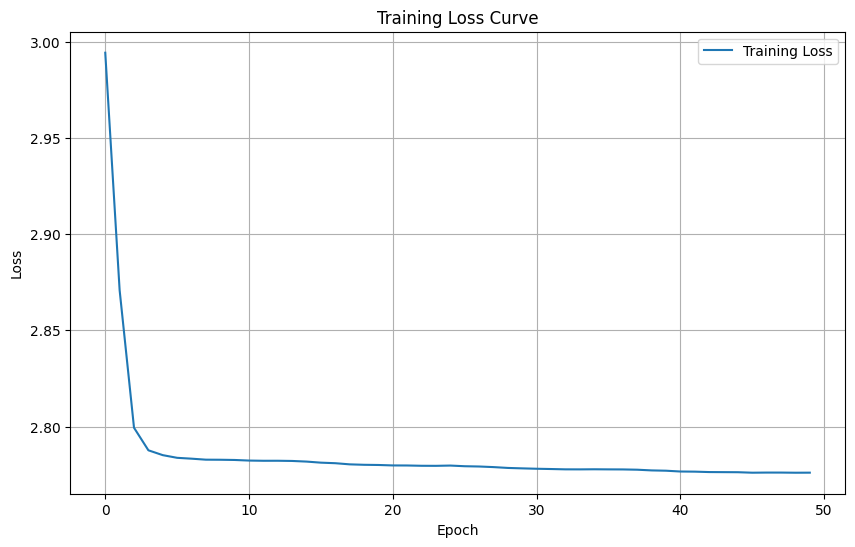


🎉 Training finished! You can now load the trained model for inference.
To load the trained model:
  checkpoint = torch.load('checkpoints/best_model.pth')
  model.load_state_dict(checkpoint['model_state_dict'])


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

# ==============================
# 🔧 训练配置
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 模型参数
img_size = 128
in_channels = 20
class_num = 16
patch_size = 8
model_size = 'base'
lora_rank = 8
lora_alpha = 16

# 训练参数
batch_size = 8
learning_rate = 1e-4  # LoRA 通常用较小的学习率
num_epochs = 50
warmup_epochs = 5     # 前5个epoch学习率线性增长
weight_decay = 0.01

# 保存路径
save_dir = "checkpoints"
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "best_model.pth")
last_model_path = os.path.join(save_dir, "last_model.pth")

print("Training configuration:")
print(f"  Batch size: {batch_size}")
print(f"  Learning rate: {learning_rate}")
print(f"  Epochs: {num_epochs}")
print(f"  LoRA rank: {lora_rank}, alpha: {lora_alpha}")

# ==============================
# 1. 构建模型（加载预训练权重）
# ==============================
print("\n=== Building model with pretrained weights ===")

# 构建模型
model = SpatOnlyLoRA(
    img_size=img_size,
    in_channels=in_channels,
    patch_size=patch_size,
    classes=class_num,
    model_size=model_size,
    lora_rank=lora_rank,
    lora_alpha=lora_alpha
).to(device)

# 加载预训练权重
pretrained_path = "spat-base.pth"
if os.path.exists(pretrained_path):
    try:
        state_dict = torch.load(pretrained_path, map_location=device)
        # 只加载 encoder 部分的权重（忽略分类头）
        encoder_state_dict = {}
        for k, v in state_dict.items():
            if k.startswith('encoder.'):
                encoder_state_dict[k.replace('encoder.', '', 1)] = v
        
        model.encoder.load_state_dict(encoder_state_dict, strict=False)
        print(f"✅ Loaded pretrained encoder weights from {pretrained_path}")
    except Exception as e:
        print(f"⚠️  Could not load pretrained weights: {e}")
        print("   Using randomly initialized model")
else:
    print(f"⚠️  Pretrained file {pretrained_path} not found")

# ==============================
# 2. 冻结主干网络，只训练 LoRA 和分类头
# ==============================
print("\n=== Setting up trainable parameters ===")

# 冻结所有参数
for param in model.parameters():
    param.requires_grad = False

# 解冻 LoRA 参数（通常 LoRA 层会自动设置为 trainable）
lora_params = []
for name, param in model.named_parameters():
    if 'lora' in name.lower() or 'lora_' in name:  # 根据你的 LoRA 实现调整
        param.requires_grad = True
        lora_params.append(param)
        print(f"  ✅ Unfrozen: {name}")

# 解冻分类头
for name, param in model.cls_head.named_parameters():
    param.requires_grad = True
    print(f"  ✅ Unfrozen: cls_head.{name}")

# 检查总的可训练参数
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable ratio: {total_params/sum(p.numel() for p in model.parameters()):.2%}")

# ==============================
# 3. 准备数据（你需要替换这部分为你的实际数据加载）
# ==============================
print("\n=== Loading training data ===")

# TODO: 替换为你的实际数据加载逻辑
# 这里用模拟数据作为示例
def load_your_data():
    """
    替换这个函数为你的实际数据加载逻辑
    返回: X_train (N, C, H, W), y_train (N, H, W) 或 (N, H*W)
    """
    # 模拟训练数据（替换为你的实际数据）
    N_train = 100  # 训练样本数
    X_train = torch.randn(N_train, in_channels, img_size, img_size)
    # y_train 应该是类别标签 (0 到 class_num-1)
    y_train = torch.randint(0, class_num, (N_train, img_size, img_size))
    
    return X_train, y_train

try:
    X_train, y_train = load_your_data()
    print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")
    
    # 创建数据集
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    
    print(f"Number of training batches: {len(train_loader)}")
    
except Exception as e:
    print(f"❌ Error loading data: {e}")
    print("Please implement your actual data loading function above")
    # 如果没有实际数据，用模拟数据继续
    N_train = 50
    X_train = torch.randn(N_train, in_channels, img_size, img_size)
    y_train = torch.randint(0, class_num, (N_train, img_size, img_size))
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    print("Using simulated data for demonstration")

# ==============================
# 4. 设置优化器和损失函数
# ==============================
print("\n=== Setting up optimizer and loss ===")

# 优化器：只优化可训练参数
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=learning_rate,
    weight_decay=weight_decay
)

# 损失函数：交叉熵（适用于多分类）
criterion = nn.CrossEntropyLoss(ignore_index=-1)  # ignore_index 可用于处理无效像素

# 学习率调度器：warmup + cosine decay
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=max(1, num_epochs // 4),  # 每1/4周期重启
    T_mult=1,
    eta_min=1e-6
)

print("✅ Optimizer and scheduler set up")

# ==============================
# 5. 训练循环
# ==============================
print("\n=== Starting training ===")

best_loss = float('inf')
train_losses = []

for epoch in range(num_epochs):
    model.train()
    
    # 学习率 warmup
    if epoch < warmup_epochs:
        warmup_lr = learning_rate * (epoch + 1) / warmup_epochs
        for param_group in optimizer.param_groups:
            param_group['lr'] = warmup_lr
    
    epoch_loss = 0.0
    num_batches = 0
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
    for batch_idx, (data, target) in enumerate(pbar):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        
        # 前向传播
        output = model(data)  # [B, class_num, H, W]
        
        # 计算损失
        # output: [B, class_num, H, W], target: [B, H, W]
        loss = criterion(output, target.long())
        
        # 反向传播
        loss.backward()
        
        # 梯度裁剪（防止梯度爆炸）
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1
        
        # 更新进度条
        pbar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Avg Loss': f'{epoch_loss/num_batches:.4f}',
            'LR': f'{optimizer.param_groups[0]["lr"]:.2e}'
        })
    
    avg_epoch_loss = epoch_loss / num_batches
    train_losses.append(avg_epoch_loss)
    
    # 更新学习率
    scheduler.step()
    
    print(f'Epoch {epoch+1}/{num_epochs}, Average Loss: {avg_epoch_loss:.6f}')
    
    # 保存最佳模型
    if avg_epoch_loss < best_loss:
        best_loss = avg_epoch_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_epoch_loss,
        }, best_model_path)
        print(f"  🏆 New best model saved with loss: {best_loss:.6f}")
    
    # 每10个epoch保存一次
    if (epoch + 1) % 10 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_epoch_loss,
        }, os.path.join(save_dir, f"model_epoch_{epoch+1}.pth"))

# 保存最终模型
torch.save({
    'epoch': num_epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': avg_epoch_loss,
}, last_model_path)

print(f"\n✅ Training completed!")
print(f"Best model saved to: {best_model_path}")
print(f"Last model saved to: {last_model_path}")

# ==============================
# 6. 绘制训练曲线
# ==============================
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

print("\n🎉 Training finished! You can now load the trained model for inference.")
print("To load the trained model:")
print("  checkpoint = torch.load('checkpoints/best_model.pth')")
print("  model.load_state_dict(checkpoint['model_state_dict'])")





In [6]:
# 打印标签分布
print("Label distribution:")
print(torch.unique(y_train, return_counts=True))

Label distribution:
(tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]), tensor([102685, 102436, 102941, 102176, 102323, 101913, 102474, 101923, 102265,
        102237, 102441, 102843, 102056, 102853, 102419, 102415]))


In [7]:
ls checkpoints/

best_model.pth  model_epoch_10.pth  model_epoch_30.pth  model_epoch_50.pth
last_model.pth  model_epoch_20.pth  model_epoch_40.pth  pca.pkl
